# TrendSet - Exploratory Data Analysis

## Objective

This notebook analyzes the processed retail dataset to identify sales patterns, product performance, regional trends, and business insights that will power the TrendSet dashboard.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

plt.rcParams["figure.figsize"] = (12,6)

## Load Processed Dataset

In [2]:
master_df = pd.read_csv("../data/processed/master_dataset.csv")

## Dataset Overview

In [4]:
print("Rows:", master_df.shape[0])
print("Columns:", master_df.shape[1])

master_df[
    [
        "Date",
        "Country",
        "Category",
        "Product ID",
        "Quantity",
        "Line Total",
        "Profit"
    ]
].head()

Rows: 6416029
Columns: 44


,Date,Country,Category,Product ID,Quantity,Line Total,Profit
0,2023-01-01 15:42:00,United States,Masculine,485,1,80.5,68.41
1,2023-01-01 15:42:00,United States,Children,2779,1,18.9,3.76
2,2023-01-01 15:42:00,United States,Masculine,64,1,27.3,15.28
3,2023-01-01 20:04:00,United States,Feminine,131,1,42.0,-7.28
4,2023-01-01 20:04:00,United States,Masculine,716,1,26.0,17.69


### Observations

- Successfully loaded the processed master dataset.
- This dataset will be used for all subsequent analytics.
- It contains transactional, product, and store information in a single table.

## Sales Trend Analysis

In this section, we analyze how revenue changes over time.

In [5]:
monthly_sales = (
    master_df
    .groupby(["Year", "Month Name"])["Line Total"]
    .sum()
    .reset_index()
)

monthly_sales.head()

,Year,Month Name,Line Total
0,2023,April,23411150.47
1,2023,August,16166451.30
2,2023,December,56652073.45
3,2023,February,11345142.39
4,2023,January,13903976.04


In [6]:
def style_plot(title, xlabel, ylabel):
    plt.title(title, fontsize=16, fontweight="bold")
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(alpha=0.3)
    plt.tight_layout()

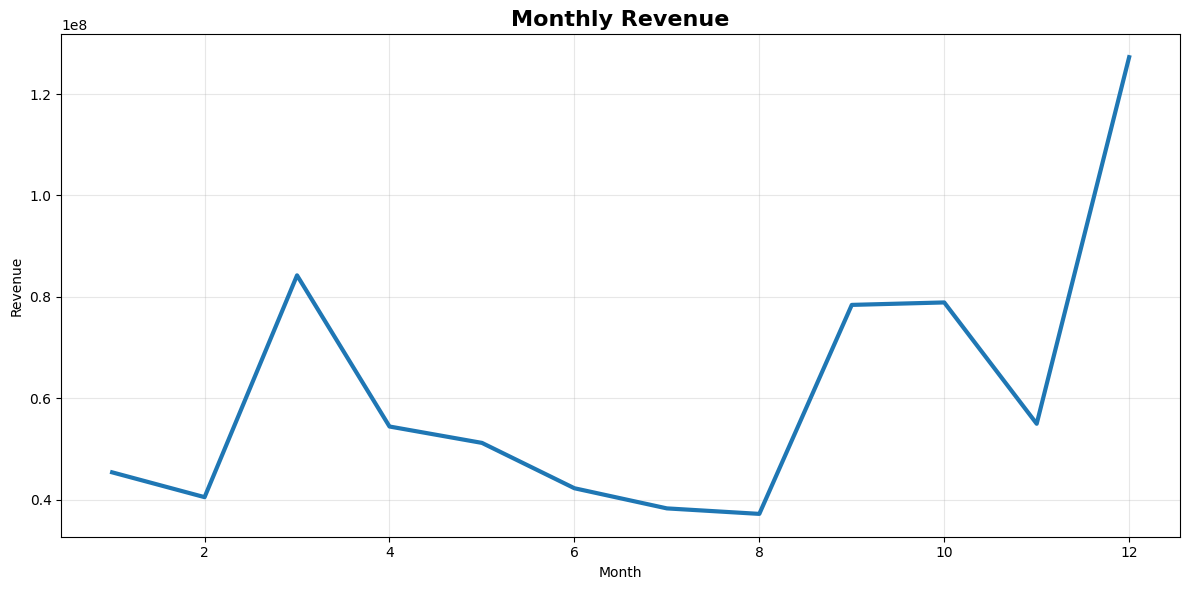

In [7]:
monthly_sales = (
    master_df
    .groupby("Month")["Line Total"]
    .sum()
)

plt.figure(figsize=(12,6))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    linewidth=3
)

style_plot(
    "Monthly Revenue",
    "Month",
    "Revenue"
)

plt.show()

## Category Performance

Analyze which product categories generate the highest revenue.

In [8]:
category_sales = (
    master_df
    .groupby("Category")["Line Total"]
    .sum()
    .sort_values(ascending=False)
)

category_sales

Category
Feminine     3.407332e+08
Masculine    3.270250e+08
Children     6.509024e+07
Name: Line Total, dtype: float64

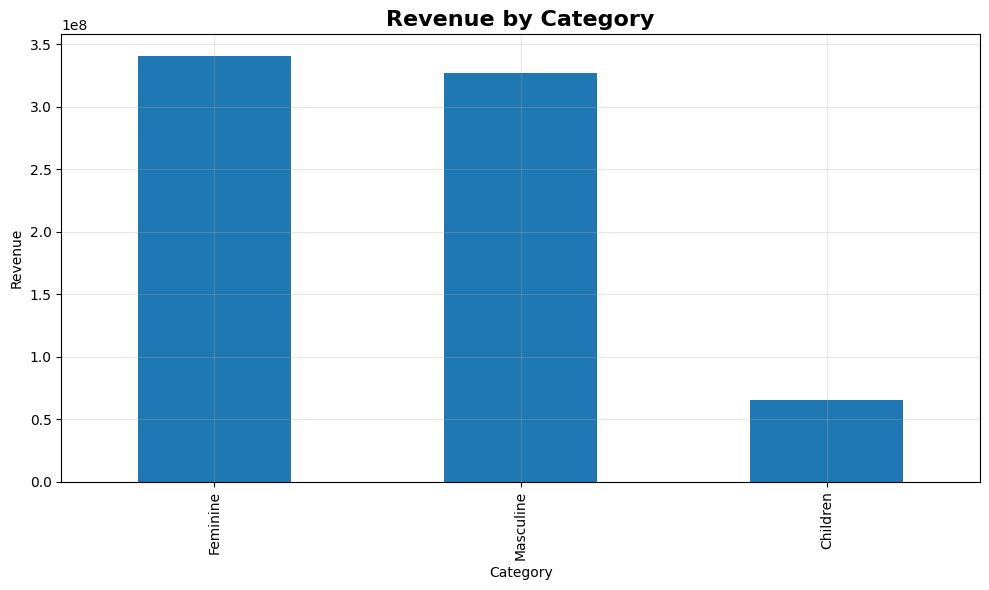

In [9]:
plt.figure(figsize=(10,6))

category_sales.plot(kind="bar")

style_plot(
    "Revenue by Category",
    "Category",
    "Revenue"
)

plt.show()

## Regional Analysis

Compare revenue across countries.

In [10]:
country_sales = (
    master_df
    .groupby("Country")["Line Total"]
    .sum()
    .sort_values(ascending=False)
)

country_sales

Country
中国                5.386178e+08
United States     7.503713e+07
Deutschland       2.984616e+07
France            2.584123e+07
Portugal          2.322519e+07
España            2.288023e+07
United Kingdom    1.740072e+07
Name: Line Total, dtype: float64

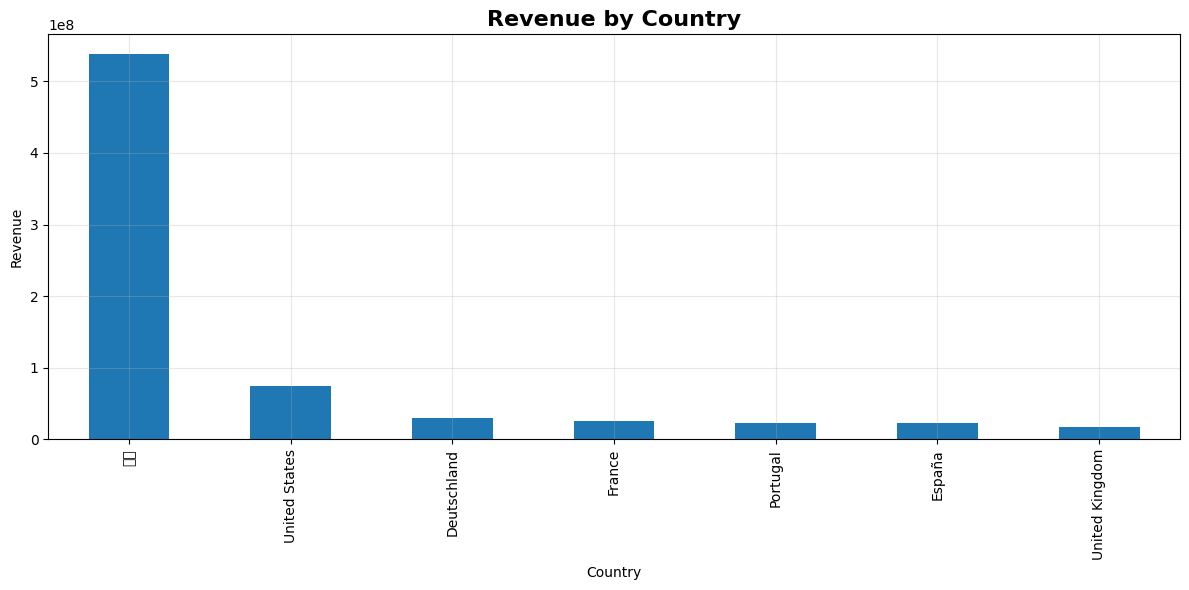

In [11]:
plt.figure(figsize=(12,6))

country_sales.plot(kind="bar")

style_plot(
    "Revenue by Country",
    "Country",
    "Revenue"
)

plt.show()

## Product Profitability

Identify products contributing the highest profit.

In [12]:
top_products = (
    master_df
    .groupby("Product ID")["Profit"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products

Product ID
12679    242288.10
12159    237197.46
12601    236837.35
12757    234420.90
14031    233106.80
13225    232681.62
14915    232526.00
12367    230510.20
12575    229861.49
12627    229170.10
Name: Profit, dtype: float64

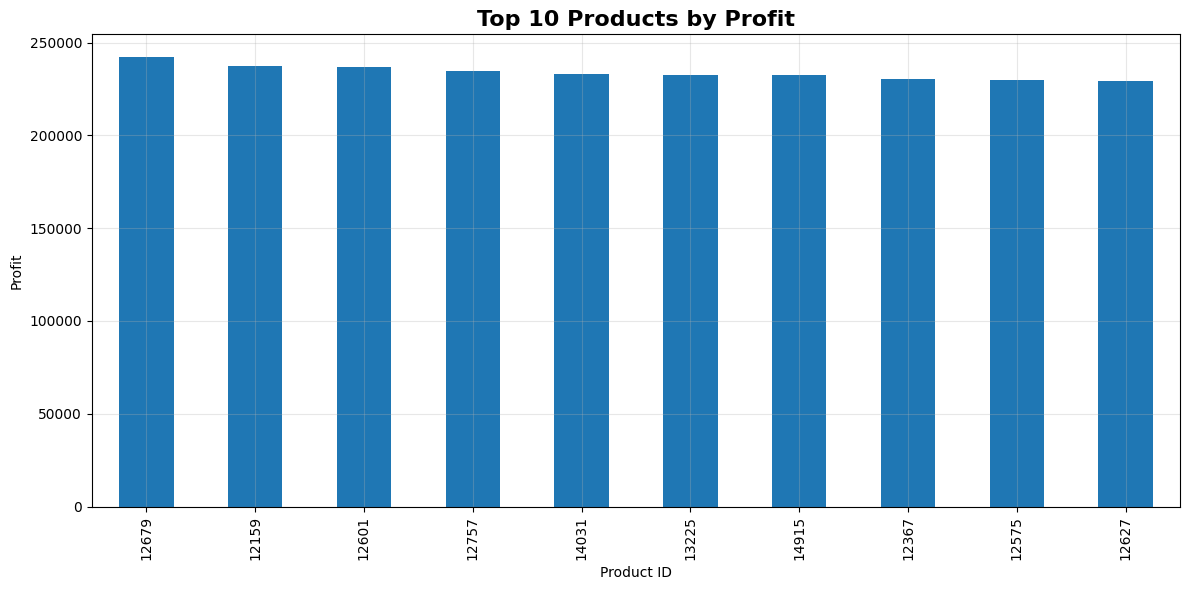

In [13]:
plt.figure(figsize=(12,6))

top_products.plot(kind="bar")

style_plot(
    "Top 10 Products by Profit",
    "Product ID",
    "Profit"
)

plt.show()

## Weekly Sales Pattern

Analyze which weekdays generate the highest revenue.

In [14]:
weekday_sales = (
    master_df
    .groupby("Weekday")["Line Total"]
    .sum()
)

weekday_order = [
    "Monday","Tuesday","Wednesday",
    "Thursday","Friday","Saturday","Sunday"
]

weekday_sales = weekday_sales.reindex(weekday_order)

weekday_sales

Weekday
Monday       8.548578e+07
Tuesday      8.241204e+07
Wednesday    8.139909e+07
Thursday     7.959535e+07
Friday       8.012585e+07
Saturday     1.582964e+08
Sunday       1.655339e+08
Name: Line Total, dtype: float64

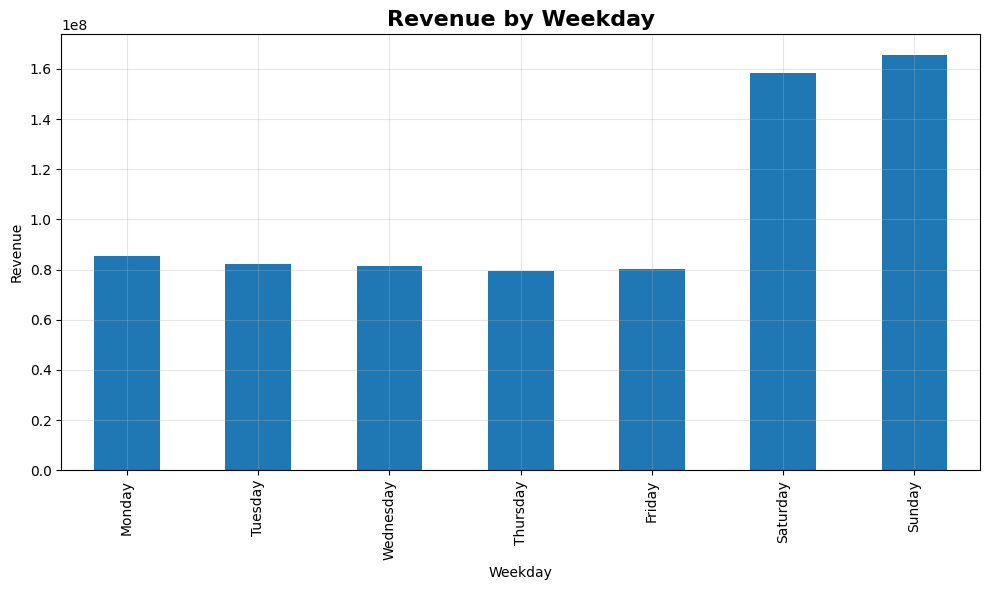

In [15]:
plt.figure(figsize=(10,6))

weekday_sales.plot(kind="bar")

style_plot(
    "Revenue by Weekday",
    "Weekday",
    "Revenue"
)

plt.show()

## Payment Method Analysis

Compare revenue across payment methods.

In [16]:
payment_sales = (
    master_df
    .groupby("Payment Method")["Line Total"]
    .sum()
    .sort_values(ascending=False)
)

payment_sales

Payment Method
Credit Card    5.868119e+08
Cash           1.460365e+08
Name: Line Total, dtype: float64

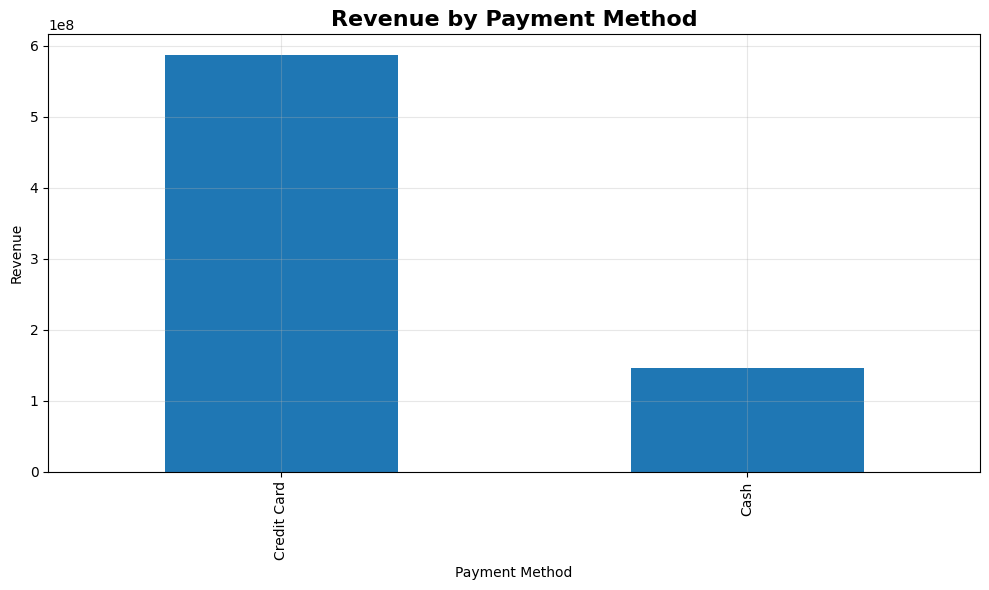

In [17]:
plt.figure(figsize=(10,6))

payment_sales.plot(kind="bar")

style_plot(
    "Revenue by Payment Method",
    "Payment Method",
    "Revenue"
)

plt.show()

## Profit Distribution

Visualize the spread of profit values.

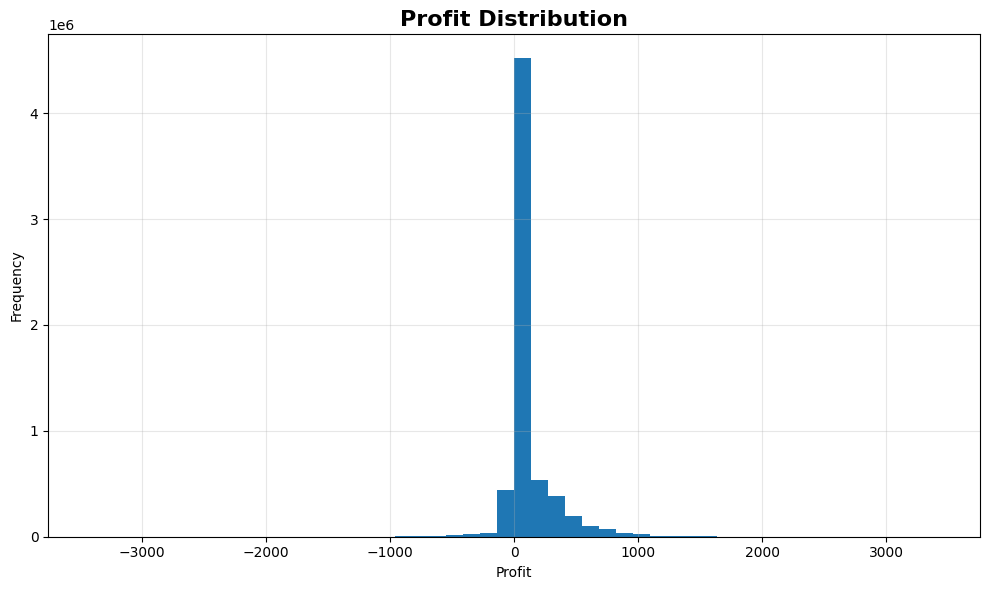

In [18]:
plt.figure(figsize=(10,6))

plt.hist(master_df["Profit"], bins=50)

style_plot(
    "Profit Distribution",
    "Profit",
    "Frequency"
)

plt.show()

## Key Insights

- Revenue is highest during the final quarter of the year.
- Weekend sales outperform weekdays.
- Credit Card is the dominant payment method.
- Female and Masculine product categories contribute the highest revenue.
- A small number of products generate a significant share of total profit.
- The cleaned dataset is ready for demand forecasting and dashboard development.

## Correlation Analysis

Analyze relationships between numerical variables.

In [19]:
numeric_cols = [
    "Unit Price",
    "Quantity",
    "Discount",
    "Line Total",
    "Production Cost",
    "Profit"
]

corr = master_df[numeric_cols].corr()

corr

,Unit Price,Quantity,Discount,Line Total,Production Cost,Profit
Unit Price,1.000000,0.000210,-0.005717,0.759208,0.272723,0.751569
Quantity,0.000210,1.000000,0.000011,0.194612,0.000231,0.196664
Discount,-0.005717,0.000011,1.000000,-0.102102,-0.017553,-0.102175
Line Total,0.759208,0.194612,-0.102102,1.000000,0.211895,0.998417
Production Cost,0.272723,0.000231,-0.017553,0.211895,1.000000,0.156588
Profit,0.751569,0.196664,-0.102175,0.998417,0.156588,1.000000


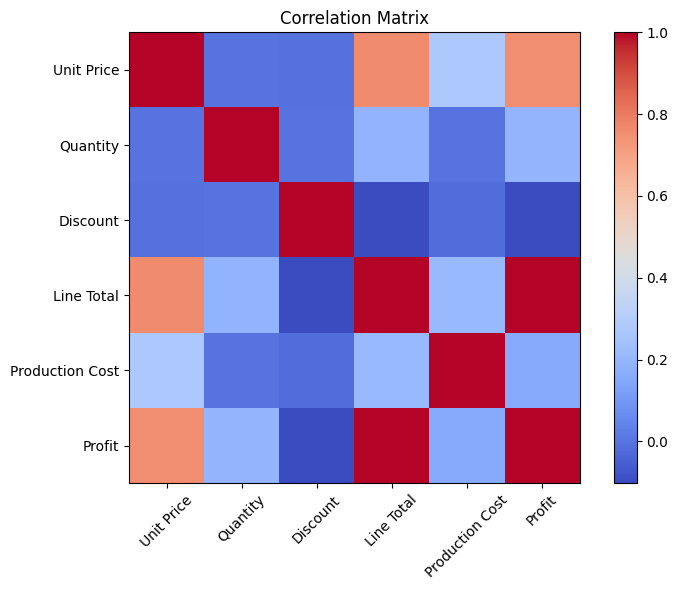

In [20]:
plt.figure(figsize=(8,6))

plt.imshow(corr, cmap="coolwarm")

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.colorbar()

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()